# Internet Game Trends Dataset

[TBD description]

### Install dependencies

Follow any warnings about needing to restart the kernel if there are issues

In [39]:
%pip install duckdb
%pip install prov
%pip install lxml

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


                                              0.0/4.0 MB ? eta -:--:--
     --                                       0.2/4.0 MB 4.7 MB/s eta 0:00:01
     --------------------                     2.1/4.0 MB 22.5 MB/s eta 0:00:01
     ---------------------------------------- 4.0/4.0 MB 32.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Run imports

In [40]:
import os
import subprocess
from prov.model import ProvDocument
from pathlib import Path
from prov.dot import prov_to_dot
from IPython.display import Image, display

### Setup Authorization credentials

Follow the steps in these links to retrieve twitch credentials:

https://api-docs.igdb.com/?python#account-creation
https://api-docs.igdb.com/?python#authentication

Once you have the relevant credentials, fill them in below:

In [72]:
TWITCH_CLIENT_ID=""
TWITCH_CLIENT_SECRET=""
TWITCH_ACCESS_TOKEN=""

Now run the following cell to write the env variables to our folder

In [73]:
env_path = '.env'

# Delete existing .env file if it exists
if os.path.exists(env_path):
    os.remove(env_path)
    print("✓ Existing .env file deleted")

env_content = f"""TWITCH_CLIENT_ID={TWITCH_CLIENT_ID}
TWITCH_CLIENT_SECRET={TWITCH_CLIENT_SECRET}
TWITCH_ACCESS_TOKEN={TWITCH_ACCESS_TOKEN}
"""

with open(env_path, 'w') as f:
    f.write(env_content)

print("✓ .env file created successfully!")

✓ Existing .env file deleted
✓ .env file created successfully!


### Run workflow

***Note: ONLY RUN ONE OF THE WORKFLOWS BELOW***

Credit - CS 598 Lab 7.1

**Option 1: Automated workflow**

Specify -f to skip retrying failed fetches. Due to the nature of rate limiting and fetching on 3rd party APIs, it may take more time to retry failed fetches. Note that this will result in a different provenance graph.

In [97]:
doc = ProvDocument()
doc.add_namespace("igtdb", "http://igtdb.org/")
doc.add_namespace("steam_api_xpaw", "https://steamapi.xpaw.me/")
doc.add_namespace("igdb_api", "https://api.igdb.com/")

agent = doc.agent("igtdb:workflow_prov", {"prov:type": "SoftwareAgent"})

# Initialize steam_applist source
def initialize_steam_applist_source():
    e = doc.entity(f"igtdb:data/steam_applist.json", {"prov:location": "data/steam_applist.json"})
    activity = doc.activity(f"steam_api_xpaw:steamapi.xpaw.me")
    doc.wasGeneratedBy(e, activity)

def initialize_igdb_source():
    doc.entity(f"igdb_api:api.igdb.com")

def run_step(activity_id, cmd, used=None, external_used=None, generated=None):
    print(f"Running {activity_id}...")
    subprocess.run(cmd, shell=True, check=True)

    activity = doc.activity(f"igtdb:{activity_id}")
    doc.wasAssociatedWith(activity, agent)

    if used:
        for u in used:
            e = doc.entity(f"igtdb:{u}", {"prov:location": u})
            doc.used(activity, e)    
    if external_used:
        for eu in external_used:
            e = doc.entity(f"{eu}")
            doc.used(activity, e)  
    if generated:
        for g in generated:
            e = doc.entity(f"igtdb:{g}", {"prov:location": g})
            doc.wasGeneratedBy(e, activity)

# Initialize provenance sources
initialize_steam_applist_source()
initialize_igdb_source()

# Run workflow steps

run_step("fetch_igdb_data", "python scripts/fetch_data_from_igdb.py",
        used=["data/steam_applist.json"],
        external_used=["igdb_api:api.igdb.com"],
        generated=["data/igdb_games.json"])

# run_step("train_rf", "python scripts/train_rf.py",
#         used=["data/processed/features.csv", "params.yaml"], 
#         generated=["results/rf/metrics.json", "data/rf/model.pkl"])

# run_step("train_logreg", "python scripts/train_logreg.py",
#         used=["data/processed/features.csv", "params.yaml"], 
#         generated=["results/logreg/metrics.json", "data/logreg/model.pkl"])

# run_step("compare_models", "python scripts/compare_models.py",
#          used=["results/logreg/metrics.json", "results/rf/metrics.json"], 
#          generated=["results/compare/metrics_compare.csv"])

doc.serialize("workflow_prov.json", format="json")
doc.serialize("workflow_prov.nt", format="rdf", rdf_format='nt', encoding="utf-8")
print("PROV-JSON written to workflow_prov.nt")

Running fetch_igdb_data...
PROV-JSON written to workflow_prov.nt


**Option 2: Manual workflow**

Also a fallback to option 1, follow the sequence of instructions to run the workflow

### Run provenance

Run the following cells to report the provenance of the workflow

**Visualize provenance graph**

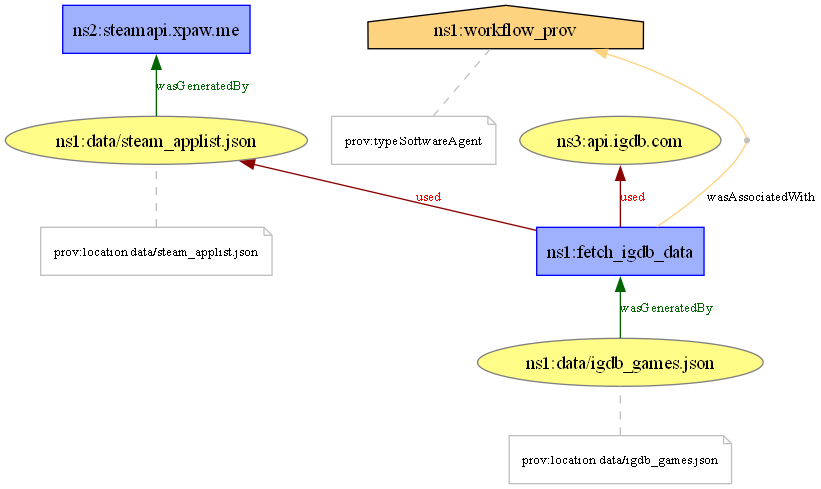

In [95]:
# Visualize provenance
doc = ProvDocument().deserialize("workflow_prov.nt", format="rdf", rdf_format="nt")
dot = prov_to_dot(doc)
display(Image(dot.create_png()))